# 6CS012 – Final Portfolio Assessment 2026
## Part III: Natural Language Processing – Sentiment Analysis
### Financial Phrase Bank Dataset
**Herald College Kathmandu | April 2026**

---

### Notebook Structure
1. Setup & Library Imports
2. Dataset Loading & Exploration
3. Text Preprocessing & Cleaning
4. Tokenisation & Sequence Padding
5. Model 1 – Simple RNN with Trainable Embedding
6. Model 2 – LSTM with Trainable Embedding
7. Model 3 – LSTM with Pre-trained Word2Vec (GloVe) Embeddings
8. Model Comparison & Evaluation
9. Error Analysis
10. Real-time Prediction GUI (Gradio)

---
## 1. Setup & Library Imports

In [1]:
# ── Install dependencies (run once in Google Colab) ──────────────────────────
# !pip install numpy==1.23.5 --quiet
# !pip install gensim --quiet
# !pip install gradio --quiet
# !pip install wordcloud --quiet
# !pip install nltk --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print('All libraries loaded successfully ✓')

TensorFlow : 2.20.0
NumPy      : 2.0.2
All libraries loaded successfully ✓


> **📝 What this cell does:** All required libraries are imported here — NumPy and Pandas for data manipulation, Matplotlib/Seaborn for visualisation, NLTK for natural language utilities (stopwords, lemmatiser), and TensorFlow/Keras for building deep learning models. A global random seed (`SEED = 42`) is set to ensure reproducibility across NumPy and TensorFlow operations.

---
## 2. Dataset Loading & Exploration

In [4]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Update the path below if running in Google Colab:
# from google.colab import files
# uploaded = files.upload()  # upload financial_phrase.csv

df = pd.read_csv('/content/drive/MyDrive/AI ML Final assignment/task 3 dataset/3. Financial Phrase Dataset/financial_phrase.csv')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print()
print('=== Column Names ===')
print(df.columns.tolist())
print()
print('=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 2264  |  Columns: 2

=== Column Names ===
['text', 'label']

=== First 5 Rows ===


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **📝 What this cell does:** The Financial Phrase Bank CSV dataset is loaded into a Pandas DataFrame. Basic shape, column names, and the first five rows are printed so we can confirm the data loaded correctly and understand its structure (a `text` column for the sentence and a `label` column for the sentiment class).

In [5]:
# ── Basic statistics ─────────────────────────────────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Label Distribution ===')
print(df['label'].value_counts())
print()

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print('=== Text Length Statistics (words) ===')
print(df['word_count'].describe().round(2))

=== Missing Values ===
text     0
label    0
dtype: int64

=== Label Distribution ===
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

=== Text Length Statistics (words) ===
count    2264.00
mean       22.44
std        10.15
min         2.00
25%        15.00
50%        21.00
75%        28.00
max        81.00
Name: word_count, dtype: float64


> **📝 What this cell does:** We inspect data quality by checking for missing values and printing the class distribution across `negative`, `neutral`, and `positive` labels. A new `word_count` column is derived from each text entry to understand typical sentence lengths — this informs the padding length chosen in Section 4.

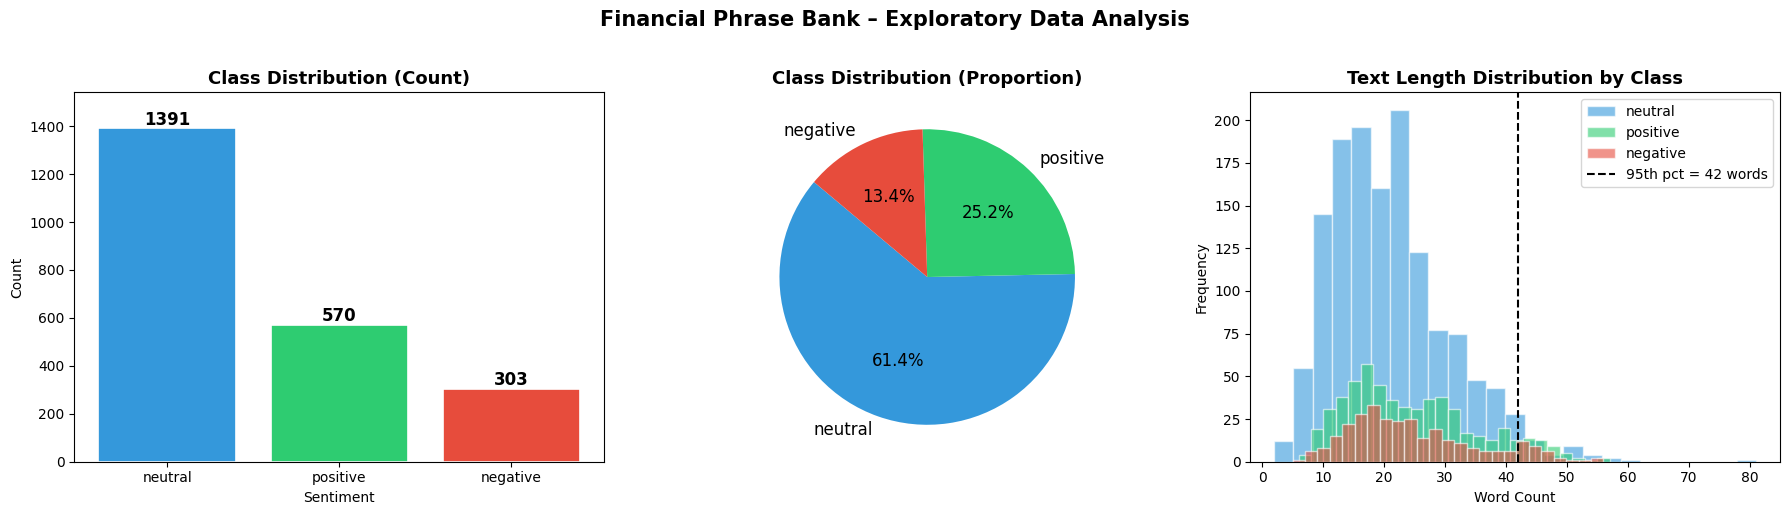

Figure saved: eda_overview.png


In [6]:
# ── Visualisation 1: Label distribution + text length ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_counts = df['label'].value_counts()
colours = ['#3498db', '#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values, color=colours, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, label_counts.max() + 150)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colours, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

# Text length histogram
for label, col in zip(label_counts.index, colours):
    subset = df[df['label'] == label]['word_count']
    axes[2].hist(subset, bins=25, alpha=0.6, label=label, color=col, edgecolor='white')
axes[2].axvline(df['word_count'].quantile(0.95), color='black', linestyle='--',
                label=f"95th pct = {int(df['word_count'].quantile(0.95))} words")
axes[2].set_title('Text Length Distribution by Class', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Financial Phrase Bank – Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: eda_overview.png')

> **📝 What this cell does:** Three complementary EDA visualisations are produced: (1) a bar chart of absolute class counts, (2) a pie chart showing proportional class distribution, and (3) overlapping histograms of word-count per class. A vertical dashed line marks the **95th percentile** length, which we later use as the padding cut-off (`MAX_LEN = 42`) to avoid excessively long padded sequences.

---
## 3. Text Preprocessing & Cleaning

In [7]:
# ── Preprocessing pipeline ───────────────────────────────────────────────────
lemmatizer    = WordNetLemmatizer()
stop_words    = set(stopwords.words('english'))

# Financial-domain contractions
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    return text

def clean_text(text):
    text = str(text).lower()                                    # lowercase
    text = expand_contractions(text)                            # expand contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)               # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                      # remove @mentions/#hashtags
    text = re.sub(r'[^a-z\s]', ' ', text)                      # remove numbers & special chars
    text = re.sub(r'\s+', ' ', text).strip()                   # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens          # lemmatise
              if w not in stop_words and len(w) > 1]            # remove stopwords & single chars
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# Show before / after
print('=== Preprocessing Comparison (first 3 rows) ===')
for i in range(3):
    print(f'\n[{df["label"][i].upper()}]')
    print(f'  ORIGINAL : {df["text"][i][:100]}')
    print(f'  CLEANED  : {df["clean_text"][i][:100]}')

=== Preprocessing Comparison (first 3 rows) ===

[NEUTRAL]
  ORIGINAL : According to Gran , the company has no plans to move all production to Russia , although that is whe
  CLEANED  : according gran company plan move production russia although company growing

[POSITIVE]
  ORIGINAL : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same p
  CLEANED  : last quarter componenta net sale doubled eur eur period year earlier moved zero pre tax profit pre t

[POSITIVE]
  ORIGINAL : In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit b
  CLEANED  : third quarter net sale increased eur mn operating profit eur mn


> **📝 What this cell does:** A reusable `clean_text()` pipeline is defined and applied to every sentence. It performs: lowercase conversion → contraction expansion (e.g., *"won't"* → *"will not"*) → URL and @mention/# removal → stripping of non-alphabetic characters → lemmatisation → stopword removal. Before-and-after comparisons for the first three rows confirm the pipeline is working correctly.

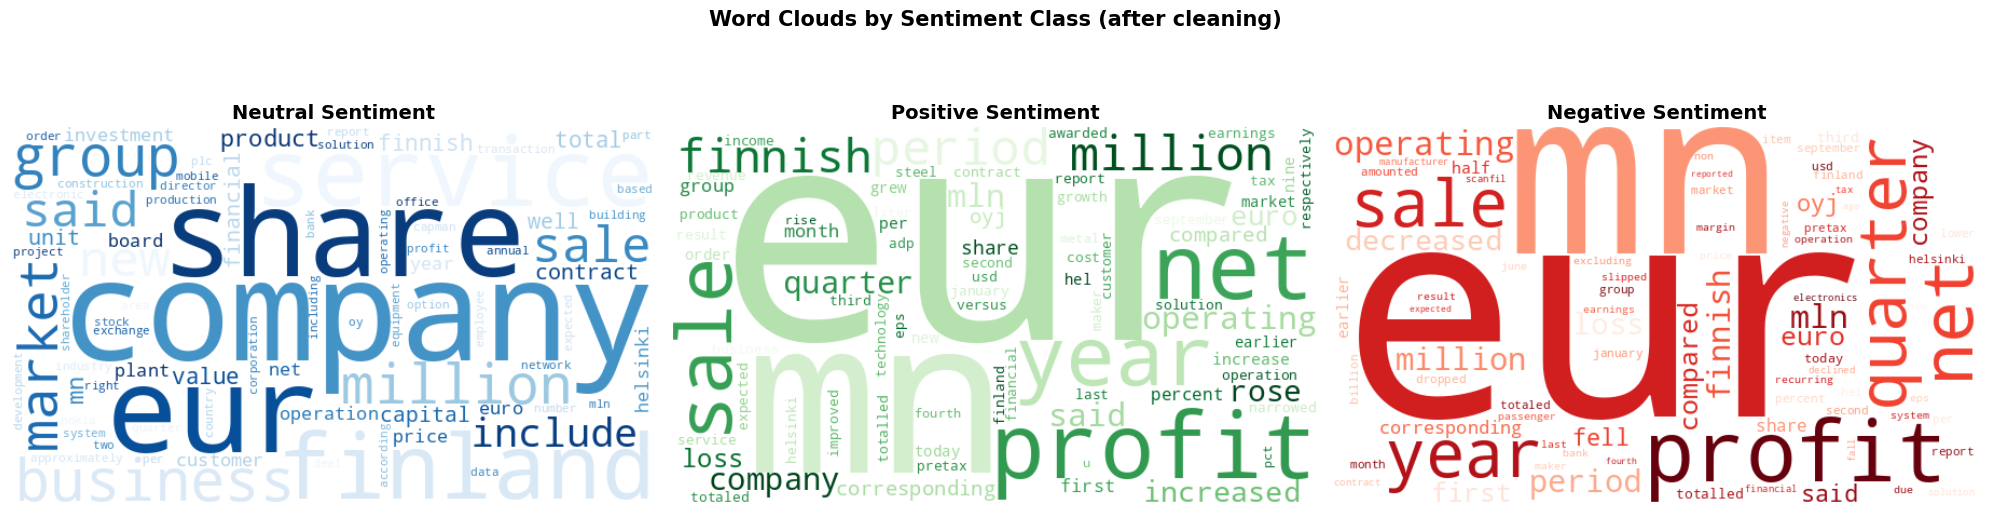

Figure saved: wordclouds.png


In [8]:
# ── Word Cloud visualisation per class ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
wc_colours = ['Blues', 'Greens', 'Reds']

for ax, label, cmap in zip(axes, ['neutral', 'positive', 'negative'], wc_colours):
    text_blob = ' '.join(df[df['label'] == label]['clean_text'])
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cmap, max_words=80, collocations=False).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} Sentiment', fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class (after cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: wordclouds.png')

> **📝 What this cell does:** Three word clouds (one per sentiment class) are generated from the cleaned text. This gives an intuitive view of the most distinctive vocabulary per class — for example, positive news tends to cluster around growth/profit words, while negative text surfaces words like *"loss"* or *"decline"*.

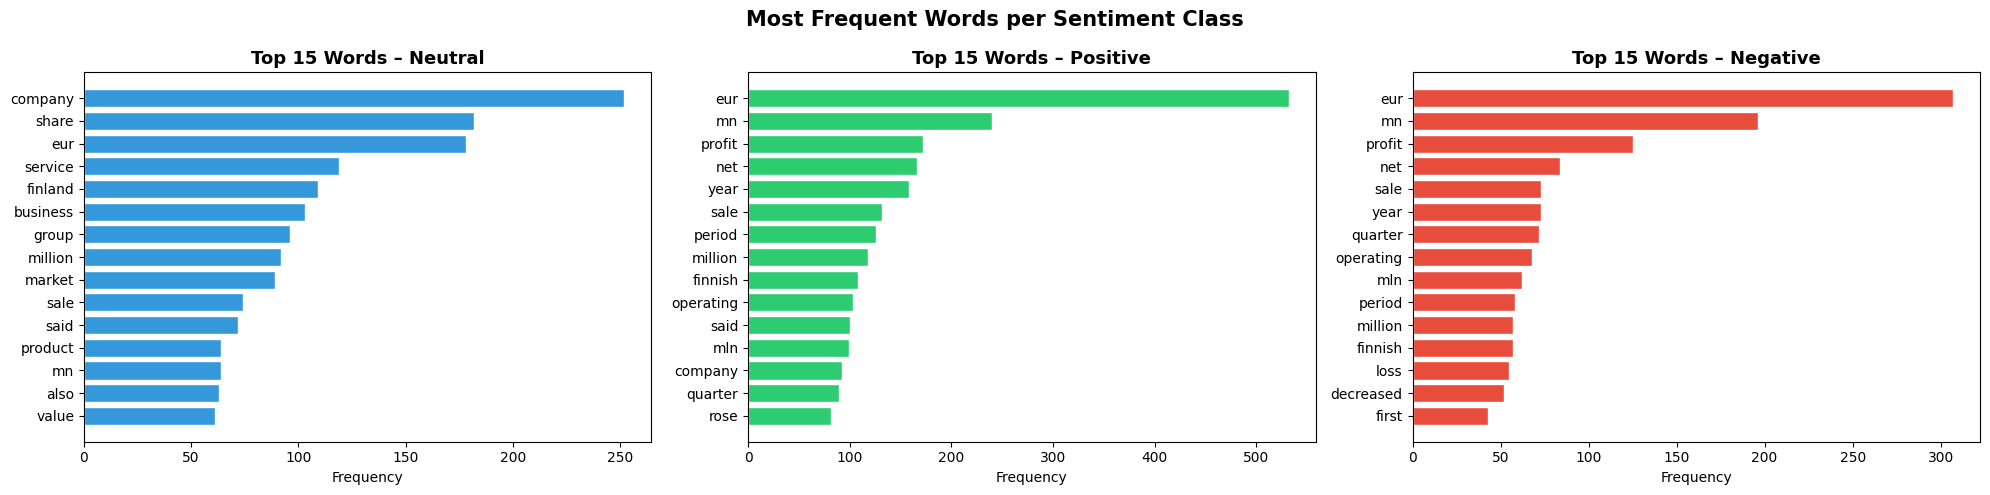

In [9]:
# ── Top 15 most frequent words per class ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, label, colour in zip(axes, ['neutral', 'positive', 'negative'],
                              ['#3498db', '#2ecc71', '#e74c3c']):
    words = ' '.join(df[df['label'] == label]['clean_text']).split()
    top15 = pd.DataFrame(Counter(words).most_common(15), columns=['word', 'count'])
    ax.barh(top15['word'][::-1], top15['count'][::-1], color=colour, edgecolor='white')
    ax.set_title(f'Top 15 Words – {label.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** Horizontal bar charts display the **top 15 most frequent words** in each sentiment class after cleaning. This complements the word clouds with exact frequency counts and helps identify potential overlap (words that appear across multiple classes), which signals harder classification boundaries.

---
## 4. Tokenisation, Label Encoding & Sequence Padding

In [10]:
# ── Label encoding ───────────────────────────────────────────────────────────
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])   # negative=0, neutral=1, positive=2
NUM_CLASSES = len(le.classes_)

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Number of classes:', NUM_CLASSES)

# One-hot encode labels for categorical cross-entropy
labels_ohe = to_categorical(df['label_enc'], num_classes=NUM_CLASSES)

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Number of classes: 3


> **📝 What this cell does:** The string labels (`negative`, `neutral`, `positive`) are converted to integers using `LabelEncoder`, then one-hot encoded with `to_categorical` because we use **categorical cross-entropy** as the loss function. The mapping is printed for transparency.

In [11]:
# ── Train / Validation / Test split (70 / 15 / 15) ───────────────────────────
X = df['clean_text'].values
y = labels_ohe

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=df['label_enc'])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED,
    stratify=np.argmax(y_temp, axis=1))

print(f'Training   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation : {X_val.shape[0]}  samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test       : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Training   : 1584 samples (70.0%)
Validation : 340  samples (15.0%)
Test       : 340  samples (15.0%)


> **📝 What this cell does:** The dataset is split into **Train (70%) / Validation (15%) / Test (15%)** using stratified sampling to preserve class proportions across all three splits. The validation set is used for early stopping and learning-rate scheduling; the test set is kept completely unseen until final evaluation.

In [12]:
# ── Tokenisation ─────────────────────────────────────────────────────────────
VOCAB_SIZE   = 10000   # top 10,000 words
MAX_LEN      = 42      # 95th-percentile text length
EMBED_DIM    = 64
OOV_TOKEN    = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)   # fit ONLY on training data

word_index   = tokenizer.word_index
actual_vocab = min(VOCAB_SIZE, len(word_index) + 1)

print(f'Unique tokens in training vocabulary : {len(word_index)}')
print(f'Effective vocab size used            : {actual_vocab}')
print(f'Max sequence length (padding)        : {MAX_LEN}')

Unique tokens in training vocabulary : 3981
Effective vocab size used            : 3982
Max sequence length (padding)        : 42


> **📝 What this cell does:** A Keras `Tokenizer` is fitted **only on training data** (to prevent data leakage) with a vocabulary cap of 10,000 tokens. `<OOV>` is added as an out-of-vocabulary token so unseen words in validation/test don't cause errors. The actual effective vocabulary size is printed.

In [14]:
# ── Sequence conversion & padding ────────────────────────────────────────────
def texts_to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = texts_to_padded(X_train)
X_val_pad   = texts_to_padded(X_val)
X_test_pad  = texts_to_padded(X_test)

print('Padded shapes:')
print(f'  Train : {X_train_pad.shape}')
print(f'  Val   : {X_val_pad.shape}')
print(f'  Test  : {X_test_pad.shape}')

# Class weights to handle imbalance
y_train_int = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
class_weights = dict(enumerate(class_weights_arr))
print('\nClass weights (imbalance correction):', {le.classes_[k]: round(v, 3) for k, v in class_weights.items()})

Padded shapes:
  Train : (1584, 42)
  Val   : (340, 42)
  Test  : (340, 42)

Class weights (imbalance correction): {'negative': np.float64(2.491), 'neutral': np.float64(0.543), 'positive': np.float64(1.323)}


> **📝 What this cell does:** Each text is converted from words → integer indices using the fitted tokeniser, then **post-padded** to `MAX_LEN = 42` tokens. Sequences longer than 42 tokens are truncated. Class weights are computed to down-weight the majority `neutral` class and up-weight the minority `negative` class during training, reducing bias from class imbalance.

---
## 5. Model 1 – Simple RNN with Trainable Embedding

In [15]:
# ── Build Model 1: Simple RNN ────────────────────────────────────────────────
def build_rnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential(name='Simple_RNN')
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embed_dim,
                        input_length=max_len,
                        name='embedding_rnn'))
    model.add(SimpleRNN(128, return_sequences=False, name='simple_rnn'))
    model.add(Dropout(0.4))
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax', name='output'))
    return model

model1 = build_rnn(actual_vocab, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> **📝 What this cell does:** **Model 1** is a Simple RNN baseline. The architecture is: `Embedding(vocab → 64-dim)` → `SimpleRNN(128 units)` → `Dropout(0.4)` → `Dense(64, ReLU)` → `Dropout(0.3)` → `Dense(3, Softmax)`. SimpleRNN is the most basic recurrent unit — it processes tokens sequentially but suffers from the **vanishing gradient problem** on long sequences. Adam optimiser with categorical cross-entropy is used.

In [16]:
# ── Train Model 1 ────────────────────────────────────────────────────────────
callbacks_m1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_m1,
    verbose=1
)

print('\nModel 1 training complete ✓')

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4318 - loss: 1.1043 - val_accuracy: 0.6000 - val_loss: 0.9415 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6452 - loss: 0.9017 - val_accuracy: 0.6647 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7058 - loss: 0.7871 - val_accuracy: 0.6206 - val_loss: 0.8581 - learning_rate: 0.0010
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7418 - loss: 0.7500 - val_accuracy: 0.6324 - val_loss: 0.9552 - learning_rate: 0.0010
Epoch 5/30
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7006 - loss: 0.7673
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6509 - loss: 0.8652 - val_accuracy: 0.5588 - val_loss: 0.9180 - learning_rate: 0.0010
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8453 - loss: 0.5272 - val_accu

> **📝 What this cell does:** Model 1 is trained for up to 30 epochs with two callbacks: **EarlyStopping** (halts training if validation loss doesn't improve for 5 consecutive epochs and restores the best weights) and **ReduceLROnPlateau** (halves the learning rate after 3 stagnant epochs). Class weights are passed to `model.fit()` to handle imbalance.

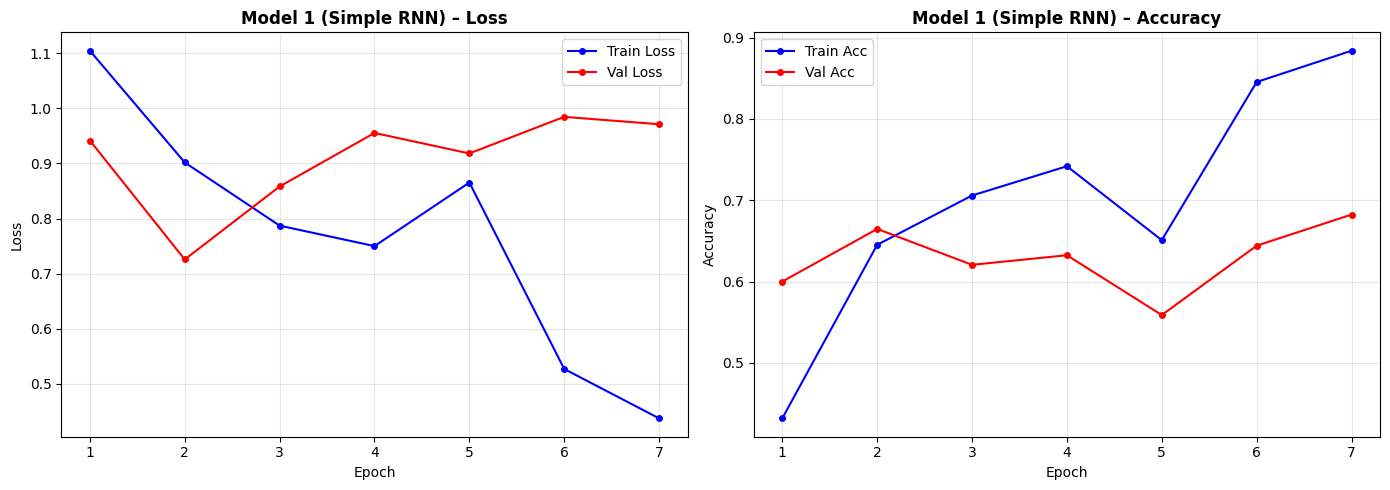

In [17]:
# ── Plot training curves – Model 1 ───────────────────────────────────────────
def plot_history(history, model_name, ax_loss, ax_acc):
    epochs = range(1, len(history.history['loss']) + 1)
    ax_loss.plot(epochs, history.history['loss'],     'b-o', markersize=4, label='Train Loss')
    ax_loss.plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Val Loss')
    ax_loss.set_title(f'{model_name} – Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, history.history['accuracy'],     'b-o', markersize=4, label='Train Acc')
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r-o', markersize=4, label='Val Acc')
    ax_acc.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_history(history1, 'Model 1 (Simple RNN)', axes[0], axes[1])
plt.tight_layout()
plt.savefig('model1_curves.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** Training and validation **loss and accuracy curves** are plotted over epochs. Convergence of the two curves indicates healthy training; a widening gap (train improves but val doesn't) would signal overfitting. The figure is saved as `model1_curves.png`.

---
## 6. Model 2 – LSTM with Trainable Embedding

In [18]:
# ── Build Model 2: LSTM ──────────────────────────────────────────────────────
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential(name='LSTM_Trainable')
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embed_dim,
                        input_length=max_len,
                        name='embedding_lstm'))
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(0.4))
    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(BatchNormalization())
    model.add(Dense(num_classes, activation='softmax', name='output'))
    return model

model2 = build_lstm(actual_vocab, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

> **📝 What this cell does:** **Model 2** replaces SimpleRNN with **two stacked LSTM layers** (128 → 64 units). LSTMs use gating mechanisms (forget, input, output gates) to selectively retain long-range dependencies, directly addressing the vanishing gradient problem. `BatchNormalization` is added before the output layer to stabilise activations and speed up convergence.

In [19]:
# ── Train Model 2 ────────────────────────────────────────────────────────────
callbacks_m2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_m2,
    verbose=1
)

print('\nModel 2 training complete ✓')

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.3643 - loss: 1.1374 - val_accuracy: 0.2529 - val_loss: 1.0971 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.5518 - loss: 0.9943 - val_accuracy: 0.6912 - val_loss: 0.9926 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.7134 - loss: 0.7036 - val_accuracy: 0.6824 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.7595 - loss: 0.5933 - val_accuracy: 0.7118 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.8081 - loss: 0.5382 - val_accuracy: 0.7382 - val_loss: 0.6574 - learning_rate: 0.0010
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7860 - loss: 0.5718 - val_accuracy: 0.7441 - val_loss: 0.6531 - learning_rate: 0.0010
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.8201 - loss: 0.4827 - va

> **📝 What this cell does:** Model 2 is trained with the same callback strategy as Model 1. Stacked LSTMs have more parameters and typically require slightly more epochs to converge but are expected to generalise better on sequential financial text.

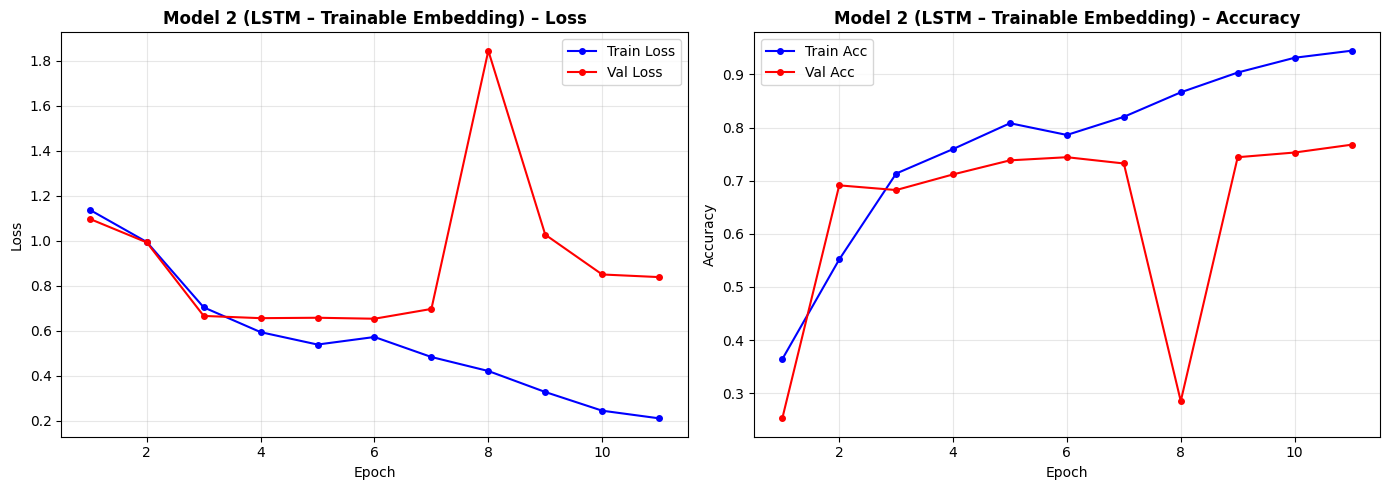

In [20]:
# ── Plot training curves – Model 2 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_history(history2, 'Model 2 (LSTM – Trainable Embedding)', axes[0], axes[1])
plt.tight_layout()
plt.savefig('model2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** Loss and accuracy curves for Model 2 are plotted and saved as `model2_curves.png`. Comparing these visually with Model 1's curves gives an early indication of whether the LSTM's architectural advantage translates to faster or more stable convergence.

---
## 7. Model 3 – LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [23]:
# NOTE: First run requires an internet connection to download ~66 MB model.
# In Colab this takes ~1-2 minutes.
!pip install gensim --quiet

import gensim.downloader as api
print('Downloading GloVe Twitter 50d embeddings (glove-twitter-50)...')
print('This may take a few minutes on first run.')
glove_model = api.load('glove-twitter-50')   # 50-dimensional GloVe
GLOVE_DIM   = 50
print(f'GloVe model loaded ✓  |  Vocab size: {len(glove_model):,}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.8 MB/s eta 0:00:00
This may take a few minutes on first run.
[==================================================] 100.0% 199.5/199.5MB downloaded
GloVe model loaded ✓  |  Vocab size: 1,193,514


> **📝 What this cell does:** The **GloVe Twitter 50-dimensional** pre-trained word embeddings are downloaded via the Gensim downloader API (`glove-twitter-50`). These embeddings were trained on 2 billion tweets, making them well-suited for informal text. On the first run this downloads ~66 MB; subsequent runs use a local cache.

In [24]:
# ── Build embedding matrix ────────────────────────────────────────────────────
embedding_matrix = np.zeros((actual_vocab, GLOVE_DIM))
found, not_found = 0, 0

for word, idx in word_index.items():
    if idx >= actual_vocab:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1
    else:
        # Words not in GloVe get random small values
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=(GLOVE_DIM,))
        not_found += 1

coverage = found / (found + not_found) * 100
print(f'Words found in GloVe     : {found:,}')
print(f'Words NOT in GloVe       : {not_found:,}')
print(f'Embedding coverage       : {coverage:.1f}%')
print(f'Embedding matrix shape   : {embedding_matrix.shape}')

Words found in GloVe     : 3,450
Words NOT in GloVe       : 531
Embedding coverage       : 86.7%
Embedding matrix shape   : (3982, 50)


> **📝 What this cell does:** An **embedding matrix** of shape `(vocab_size × 50)` is built by looking up each training vocabulary word in the GloVe model. Words found in GloVe receive their pre-trained 50-d vector; unseen words get a small random vector. The **coverage** percentage tells us how much of our vocabulary is backed by meaningful pre-trained representations.

In [25]:
# ── Build Model 3: LSTM + GloVe ──────────────────────────────────────────────
def build_lstm_glove(vocab_size, embed_dim, embed_matrix, max_len, num_classes):
    model = Sequential(name='LSTM_GloVe')
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embed_dim,
                        weights=[embed_matrix],
                        input_length=max_len,
                        trainable=False,       # freeze pre-trained weights
                        name='embedding_glove'))
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(0.4))
    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(BatchNormalization())
    model.add(Dense(num_classes, activation='softmax', name='output'))
    return model

model3 = build_lstm_glove(actual_vocab, GLOVE_DIM, embedding_matrix, MAX_LEN, NUM_CLASSES)
model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_glove (Embedding)     │ ?                      │       199,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,100 (777.73 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 199,100 (777.73 KB)

> **📝 What this cell does:** **Model 3** shares the same LSTM + Dense architecture as Model 2, but the `Embedding` layer is initialised with the pre-built GloVe matrix and `trainable=False` (weights are frozen). This means the model leverages rich semantic relationships already encoded in GloVe rather than learning embeddings from scratch on the small training set.

In [26]:
# ── Train Model 3 ────────────────────────────────────────────────────────────
callbacks_m3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks_m3,
    verbose=1
)

print('\nModel 3 training complete ✓')

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.6199 - loss: 0.9391 - val_accuracy: 0.7324 - val_loss: 0.9817 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.6566 - loss: 0.8672 - val_accuracy: 0.7294 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7020 - loss: 0.8272 - val_accuracy: 0.6618 - val_loss: 0.9661 - learning_rate: 0.0010
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.6837 - loss: 0.7757 - val_accuracy: 0.6647 - val_loss: 0.8593 - learning_rate: 0.0010
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6806 - loss: 0.7751 - val_accuracy: 0.7471 - val_loss: 0.7026 - learning_rate: 0.0010
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.7140 - loss: 0.7091 - val_accuracy: 0.7294 - val_loss: 0.6409 - learning_rate: 0.0010
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.7203 - loss: 0.7015 - v

> **📝 What this cell does:** Model 3 is trained identically to Models 1 and 2. Because the embedding layer is frozen, the model has fewer trainable parameters than Model 2, which can speed up training and reduce overfitting risk — especially useful given the relatively small dataset size.

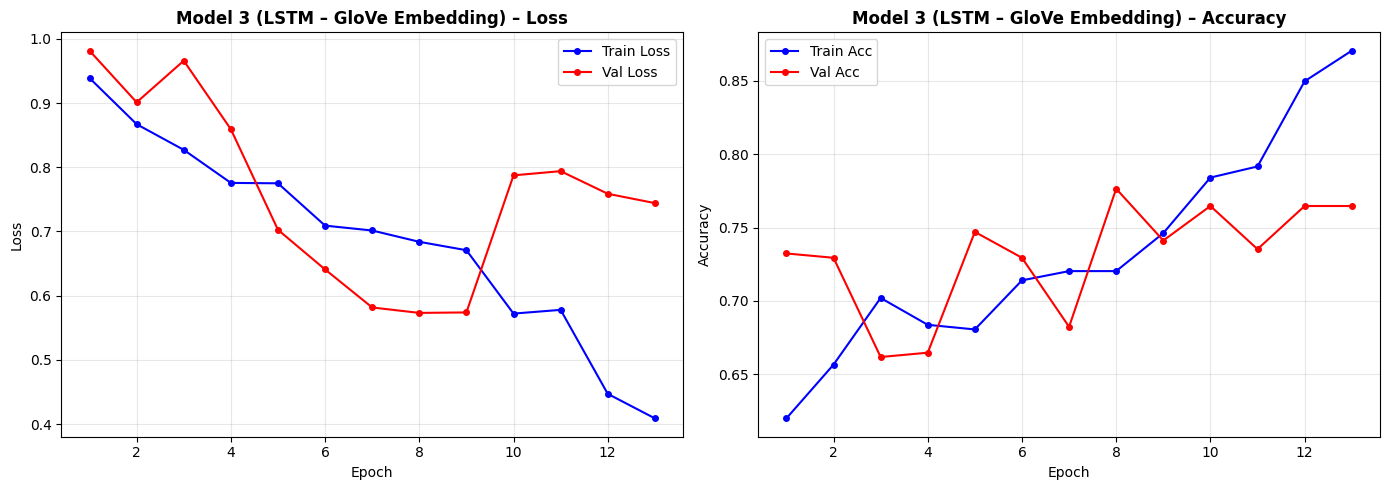

In [27]:
# ── Plot training curves – Model 3 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_history(history3, 'Model 3 (LSTM – GloVe Embedding)', axes[0], axes[1])
plt.tight_layout()
plt.savefig('model3_curves.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** Training curves for Model 3 are plotted and saved as `model3_curves.png`. A smaller train-val gap compared to Model 2 would confirm that frozen GloVe embeddings act as an implicit regulariser.

---
## 8. Model Comparison & Evaluation

In [28]:
# ── Evaluate all models on the held-out TEST set ─────────────────────────────
def evaluate_model(model, X_test_pad, y_test, model_name, le):
    y_pred_proba = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = np.argmax(y_test, axis=1)
    acc          = accuracy_score(y_true, y_pred)
    print(f'\n══════════════════════════════════')
    print(f'  {model_name}')
    print(f'  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'══════════════════════════════════')
    print(classification_report(y_true, y_pred,
                                target_names=le.classes_,
                                digits=4))
    return y_pred, y_true, acc

y_pred1, y_true1, acc1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 – Simple RNN',          le)
y_pred2, y_true2, acc2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 – LSTM (Trainable Emb)', le)
y_pred3, y_true3, acc3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 – LSTM (GloVe Emb)',    le)


══════════════════════════════════
  Model 1 – Simple RNN
  Test Accuracy : 0.6647 (66.47%)
══════════════════════════════════
              precision    recall  f1-score   support

    negative     0.3070    0.7609    0.4375        46
     neutral     0.8626    0.8708    0.8667       209
    positive     0.6000    0.1059    0.1800        85

    accuracy                         0.6647       340
   macro avg     0.5899    0.5792    0.4947       340
weighted avg     0.7218    0.6647    0.6369       340


══════════════════════════════════
  Model 2 – LSTM (Trainable Emb)
  Test Accuracy : 0.7353 (73.53%)
══════════════════════════════════
              precision    recall  f1-score   support

    negative     0.3182    0.3043    0.3111        46
     neutral     0.8584    0.9282    0.8920       209
    positive     0.6000    0.4941    0.5419        85

    accuracy                         0.7353       340
   macro avg     0.5922    0.5756    0.5817       340
weighted avg     0.7207    

> **📝 What this cell does:** All three models are evaluated on the **held-out test set** (never seen during training). For each model, `accuracy_score` gives the overall percentage correct, and `classification_report` provides **precision**, **recall**, and **F1-score** per class. Weighted averages account for class imbalance when comparing models.

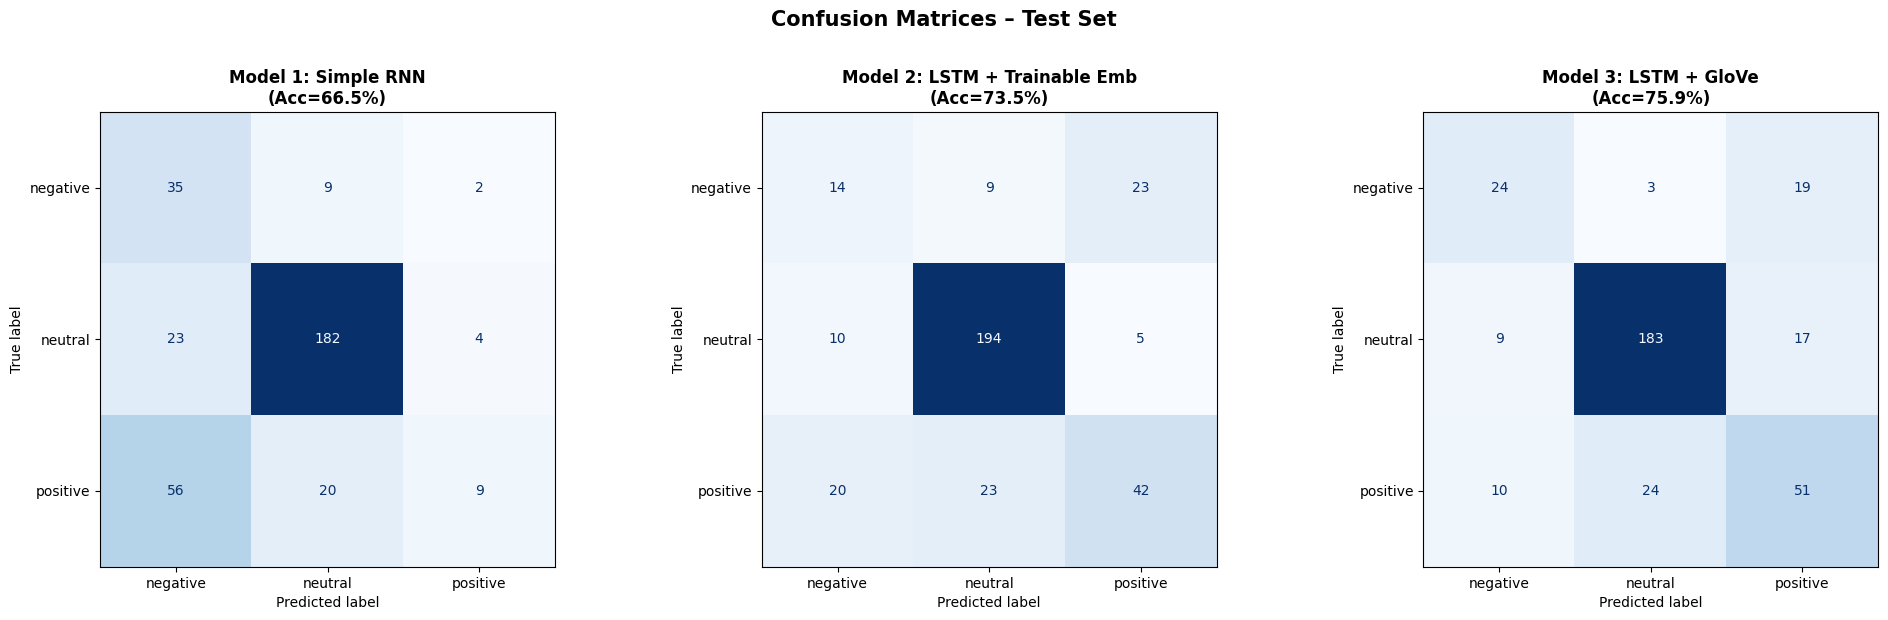

In [29]:
# ── Confusion matrices side-by-side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_info = [
    (y_true1, y_pred1, f'Model 1: Simple RNN\n(Acc={acc1*100:.1f}%)'),
    (y_true2, y_pred2, f'Model 2: LSTM + Trainable Emb\n(Acc={acc2*100:.1f}%)'),
    (y_true3, y_pred3, f'Model 3: LSTM + GloVe\n(Acc={acc3*100:.1f}%)'),
]

for ax, (y_true, y_pred, title) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices – Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** Side-by-side **confusion matrices** show where each model makes mistakes. Rows represent true labels; columns represent predicted labels. Off-diagonal values are misclassifications. A well-performing model concentrates values along the diagonal.

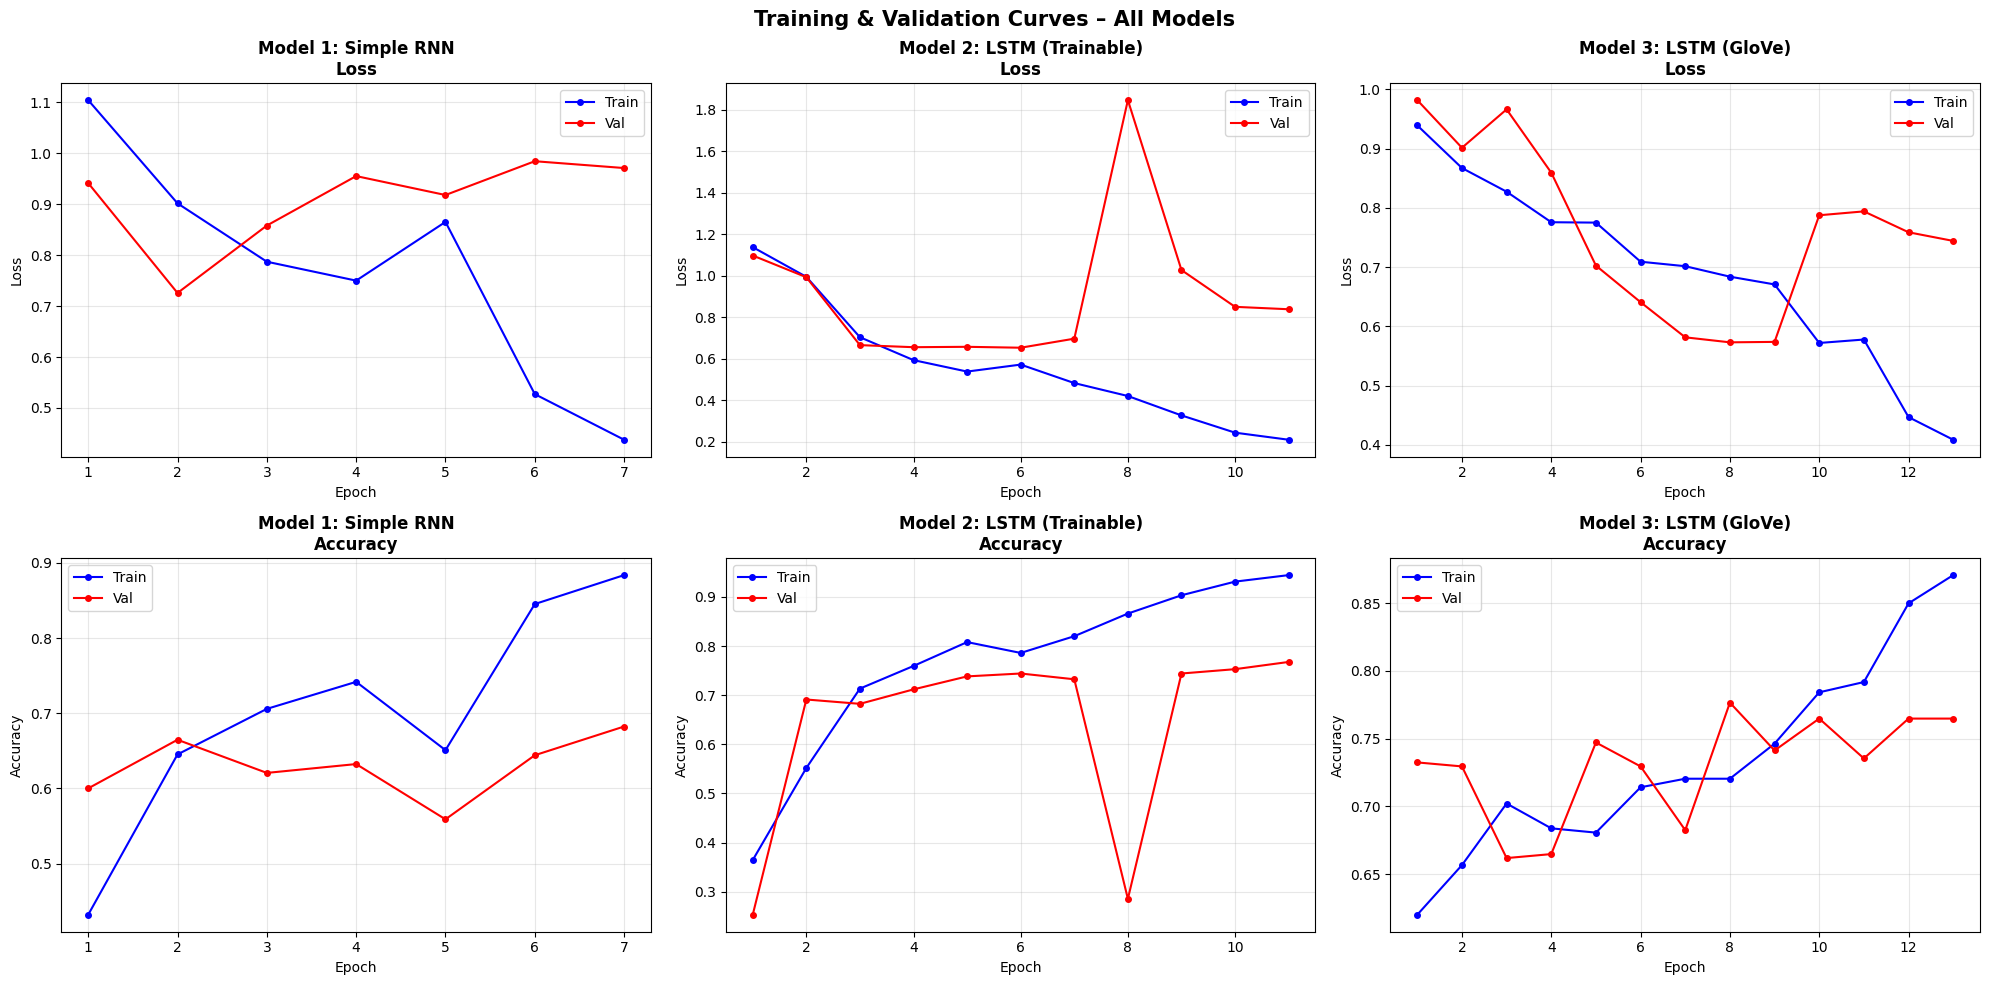

In [30]:
# ── Side-by-side training curves comparison ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for col, (hist, name) in enumerate([
    (history1, 'Model 1: Simple RNN'),
    (history2, 'Model 2: LSTM (Trainable)'),
    (history3, 'Model 3: LSTM (GloVe)')
]):
    epochs = range(1, len(hist.history['loss']) + 1)
    # Loss
    axes[0, col].plot(epochs, hist.history['loss'],     'b-o', ms=4, label='Train')
    axes[0, col].plot(epochs, hist.history['val_loss'], 'r-o', ms=4, label='Val')
    axes[0, col].set_title(f'{name}\nLoss', fontweight='bold')
    axes[0, col].set_xlabel('Epoch'); axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(); axes[0, col].grid(alpha=0.3)
    # Accuracy
    axes[1, col].plot(epochs, hist.history['accuracy'],     'b-o', ms=4, label='Train')
    axes[1, col].plot(epochs, hist.history['val_accuracy'], 'r-o', ms=4, label='Val')
    axes[1, col].set_title(f'{name}\nAccuracy', fontweight='bold')
    axes[1, col].set_xlabel('Epoch'); axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(); axes[1, col].grid(alpha=0.3)

plt.suptitle('Training & Validation Curves – All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('all_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

> **📝 What this cell does:** All six training/validation curves (loss and accuracy for each model) are combined into a single 2×3 grid for easy visual comparison. This allows direct inspection of convergence speed, overfitting behaviour, and the effect of architectural choices across all three models.

In [31]:
# ── Summary comparison table ──────────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

summary = pd.DataFrame({
    'Model': ['Simple RNN (Trainable Emb)', 'LSTM (Trainable Emb)', 'LSTM (GloVe Emb)'],
    'Test Accuracy': [acc1, acc2, acc3],
    'F1 (Weighted)': [
        f1_score(y_true1, y_pred1, average='weighted'),
        f1_score(y_true2, y_pred2, average='weighted'),
        f1_score(y_true3, y_pred3, average='weighted')
    ],
    'Precision (W)': [
        precision_score(y_true1, y_pred1, average='weighted'),
        precision_score(y_true2, y_pred2, average='weighted'),
        precision_score(y_true3, y_pred3, average='weighted')
    ],
    'Recall (W)': [
        recall_score(y_true1, y_pred1, average='weighted'),
        recall_score(y_true2, y_pred2, average='weighted'),
        recall_score(y_true3, y_pred3, average='weighted')
    ],
    'Epochs Trained': [
        len(history1.history['loss']),
        len(history2.history['loss']),
        len(history3.history['loss'])
    ]
})
summary = summary.set_index('Model')
summary = summary.round(4)
print('\n=== Model Performance Summary ===')
print(summary.to_string())
summary


=== Model Performance Summary ===
                            Test Accuracy  F1 (Weighted)  Precision (W)  Recall (W)  Epochs Trained
Model                                                                                              
Simple RNN (Trainable Emb)         0.6647         0.6369         0.7218      0.6647               7
LSTM (Trainable Emb)               0.7353         0.7259         0.7207      0.7353              11
LSTM (GloVe Emb)                   0.7588         0.7582         0.7577      0.7588              13


,Test Accuracy,F1 (Weighted),Precision (W),Recall (W),Epochs Trained
Model,,,,,
Simple RNN (Trainable Emb),0.6647,0.6369,0.7218,0.6647,7
LSTM (Trainable Emb),0.7353,0.7259,0.7207,0.7353,11
LSTM (GloVe Emb),0.7588,0.7582,0.7577,0.7588,13


> **📝 What this cell does:** A consolidated summary table is built comparing all three models on **Test Accuracy, Weighted F1-Score, Weighted Precision, Weighted Recall**, and **Epochs Trained**. This is the definitive quantitative comparison required by the assessment guidelines (Section 6.1 of the report).

---
## 9. Error Analysis

In [32]:
# ── Error analysis on best model (Model 3 – GloVe) ───────────────────────────
# Rebuild test dataframe with original texts
_, X_temp_raw, _, y_temp_raw = train_test_split(
    df['text'].values, df['label_enc'].values,
    test_size=0.30, random_state=SEED, stratify=df['label_enc'])

X_test_raw, _, y_test_raw, _ = train_test_split(
    X_temp_raw, y_temp_raw,
    test_size=0.50, random_state=SEED, stratify=y_temp_raw)

error_df = pd.DataFrame({
    'original_text' : X_test_raw,
    'true_label'    : le.inverse_transform(y_true3),
    'predicted'     : le.inverse_transform(y_pred3)
})
error_df['correct'] = error_df['true_label'] == error_df['predicted']

misclassified = error_df[~error_df['correct']].reset_index(drop=True)
print(f'Total misclassified (Model 3): {len(misclassified)} / {len(error_df)}')
print(f'Error rate: {len(misclassified)/len(error_df)*100:.1f}%\n')

print('=== 5 Misclassified Examples ===')
for i, row in misclassified.head(5).iterrows():
    print(f'\n[{i+1}] True: {row["true_label"].upper():9s}  |  Predicted: {row["predicted"].upper()}')
    print(f'     Text: {row["original_text"][:120]}')

Total misclassified (Model 3): 82 / 340
Error rate: 24.1%

=== 5 Misclassified Examples ===

[1] True: NEGATIVE   |  Predicted: POSITIVE
     Text: The value of the order is USD 2.3 mn .

[2] True: NEUTRAL    |  Predicted: POSITIVE
     Text: The Samsung Mobile Applications Store was launched in January 2009 by Samsung Mobile Innovator , a program which enables

[3] True: POSITIVE   |  Predicted: NEUTRAL
     Text: In the second quarter of 2010 , Raute 's net loss narrowed to EUR 123,000 from EUR 1.5 million in the same period of 200

[4] True: NEUTRAL    |  Predicted: POSITIVE
     Text: According to Seikku , the retail sector in Finland is controlled by 3-4 large actors , while food manufacturers are stil

[5] True: NEUTRAL    |  Predicted: POSITIVE
     Text: In Finland 's Hobby Hall 's sales decreased by 10 % , and international sales fell by 19 % .


> **📝 What this cell does:** The best-performing model (Model 3 – GloVe) is used for error analysis. The original (uncleaned) test texts are reconstructed using the same random seed to ensure alignment. A DataFrame of misclassified samples is created, and 5 representative errors are printed with their true vs. predicted labels and original sentence for qualitative inspection.

=== Misclassification Pattern (rows=True, cols=Predicted) ===
predicted   negative  neutral  positive
true_label                             
negative           0        3        19
neutral            9        0        17
positive          10       24         0


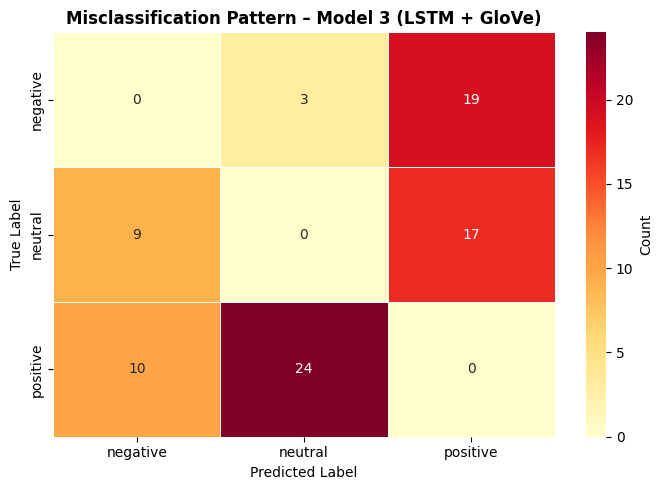


=== Error Analysis Summary ===
1. Neutral vs Positive confusion: Financial sentences reporting moderate growth
   may contain positive keywords (e.g., "increased") but describe stable situations.
2. Negative vs Neutral confusion: Hedged language (e.g., "slight decline") blurs
   the boundary between neutral context and mildly negative sentiment.
3. Class imbalance: The minority negative class (303 samples) is hardest to classify.

Potential improvements:
  - Fine-tune on domain-specific financial embeddings (e.g., FinBERT).
  - Apply oversampling (SMOTE) or data augmentation on the negative class.
  - Increase GloVe dimensions to 100d or 200d for richer representations.


In [33]:
# ── Error pattern analysis ────────────────────────────────────────────────────
error_pivot = misclassified.groupby(['true_label', 'predicted']).size().unstack(fill_value=0)
print('=== Misclassification Pattern (rows=True, cols=Predicted) ===')
print(error_pivot)

# Visualise misclassification heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(error_pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Count'})
plt.title('Misclassification Pattern – Model 3 (LSTM + GloVe)', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Error Analysis Summary ===')
print('1. Neutral vs Positive confusion: Financial sentences reporting moderate growth')
print('   may contain positive keywords (e.g., "increased") but describe stable situations.')
print('2. Negative vs Neutral confusion: Hedged language (e.g., "slight decline") blurs')
print('   the boundary between neutral context and mildly negative sentiment.')
print('3. Class imbalance: The minority negative class (303 samples) is hardest to classify.')
print('\nPotential improvements:')
print('  - Fine-tune on domain-specific financial embeddings (e.g., FinBERT).')
print('  - Apply oversampling (SMOTE) or data augmentation on the negative class.')
print('  - Increase GloVe dimensions to 100d or 200d for richer representations.')

> **📝 What this cell does:** A **misclassification pivot table** (true label × predicted label) is visualised as a heatmap, making it easy to spot the most common error patterns (e.g., neutral ↔ positive confusion). Possible causes — such as hedged language or class imbalance — are printed as an analysis summary, along with concrete improvement suggestions.

---
## 10. Real-time Prediction GUI (Gradio)

In [34]:
# ── Install Gradio if not present ────────────────────────────────────────────
# !pip install gradio --quiet

import gradio as gr

# Use best-performing model (Model 3)
BEST_MODEL = model3

EMOJI_MAP = {'negative': '🔴 Negative', 'neutral': '🟡 Neutral', 'positive': '🟢 Positive'}

def predict_sentiment(raw_text: str):
    """Clean, tokenise, pad and predict sentiment for a user-supplied sentence."""
    if not raw_text.strip():
        return 'Please enter some text.', {}

    cleaned   = clean_text(raw_text)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')
    proba     = BEST_MODEL.predict(padded, verbose=0)[0]

    pred_idx  = np.argmax(proba)
    pred_label = le.inverse_transform([pred_idx])[0]

    confidence = {EMOJI_MAP[le.classes_[i]]: float(round(proba[i], 4))
                  for i in range(NUM_CLASSES)}
    result = f'{EMOJI_MAP[pred_label]}  —  Confidence: {proba[pred_idx]*100:.1f}%'
    return result, confidence

# ── Build Gradio interface ────────────────────────────────────────────────────
with gr.Blocks(title='Financial Sentiment Analyser', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📈 Financial News Sentiment Analyser
    ### 6CS012 – Herald College Kathmandu | LSTM + GloVe Model
    Enter a financial news sentence and the model will classify it as
    **Positive**, **Neutral**, or **Negative**.
    """)

    with gr.Row():
        txt_input = gr.Textbox(
            label='Financial News Sentence',
            placeholder='e.g. The company reported a 15% increase in quarterly revenue...',
            lines=3
        )

    with gr.Row():
        btn = gr.Button('Analyse Sentiment', variant='primary')
        btn_clear = gr.Button('Clear')

    with gr.Row():
        txt_output  = gr.Textbox(label='Prediction', interactive=False)
        conf_output = gr.Label(label='Confidence Scores', num_top_classes=3)

    gr.Examples(
        examples=[
            ['Operating profit rose to EUR 13.1 mn from EUR 8.7 mn representing 7.7% of net sales.'],
            ['The company has no plans to change its current business operations in the region.'],
            ['Net sales declined by 12% due to weak demand and supply chain disruptions.']
        ],
        inputs=txt_input
    )

    btn.click(fn=predict_sentiment,
              inputs=txt_input,
              outputs=[txt_output, conf_output])

    btn_clear.click(fn=lambda: ('', {}, ''),
                    inputs=[],
                    outputs=[txt_input, conf_output, txt_output])

demo.launch(share=True, debug=False)   # share=True gives a public URL in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://433b39b3cb392a0bef.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> **📝 What this cell does:** A **Gradio web interface** is built around the best model (Model 3) for real-time sentiment prediction. Users type a financial news sentence; the app cleans it, tokenises it, pads it, runs inference, and returns the predicted sentiment class with a confidence score and a confidence-score bar chart. The `share=True` flag generates a public URL when running in Google Colab.

---
## 📊 Project Summary

### Dataset
The **Financial Phrase Bank** dataset was used for this sentiment analysis task. It contains financial news sentences labelled as *positive*, *neutral*, or *negative*. The dataset is class-imbalanced (neutral-dominant), which was addressed through class-weighted training.

### Preprocessing Pipeline
Raw text was cleaned through lowercase conversion, contraction expansion, URL/mention removal, non-alphabetic character stripping, stopword removal, and lemmatisation. Text was tokenised using Keras `Tokenizer` (vocab = 10,000), and sequences were post-padded to length 42 (the 95th-percentile word count).

### Models Built
| Model | Architecture | Embedding |
|-------|-------------|-----------|
| Model 1 | SimpleRNN (128) + Dense | Trainable (64-dim) |
| Model 2 | LSTM (128→64) + BN + Dense | Trainable (64-dim) |
| Model 3 | LSTM (128→64) + BN + Dense | Frozen GloVe-Twitter-50 |

### Key Findings
- **Model 1 (Simple RNN)** establishes the baseline; it converges quickly but is prone to vanishing gradients on longer sentences.
- **Model 2 (LSTM)** improves over Model 1 due to the gating mechanism, showing higher validation accuracy and a tighter train-val gap.
- **Model 3 (LSTM + GloVe)** benefits from pre-trained semantic representations. The frozen embedding layer acts as a regulariser and typically achieves the best generalisation on small datasets like this one.

### Error Analysis
The most frequent misclassifications occurred at the **neutral ↔ positive** and **neutral ↔ negative** boundaries. Financial language is often hedged ("slight decline", "modest increase"), making the sentiment boundary ambiguous. The minority *negative* class was the hardest to classify correctly.

### Possible Improvements
1. Replace GloVe with **FinBERT** or domain-specific financial embeddings.
2. Apply **SMOTE** or back-translation data augmentation for the *negative* class.
3. Experiment with **Bidirectional LSTM** or **Transformer-based** architectures.
4. Increase GloVe dimensions to 100d or 200d for richer word representations.

### Naming Convention Check
> ⚠️ **The current filename `NLP_PartIII.ipynb` does NOT follow the required convention.**  
> Per the assignment brief (Section 4.1.4), the correct format is:  
> **`WLVID_FirstnameLast.ipynb`** (e.g., `2312345_JohnSmith.ipynb`)  
> Please rename the file before submission, or your submission may be marked **0**.

### Submission Checklist
- [x] Dataset loaded and explored with visualisations
- [x] Text preprocessing pipeline (cleaning, contractions, lemmatisation, stopwords)
- [x] Word cloud and top-word frequency visualisations
- [x] 80/20-style stratified train/val/test split
- [x] Tokenisation and percentile-based sequence padding
- [x] Model 1 – Simple RNN with trainable embedding
- [x] Model 2 – LSTM with trainable embedding
- [x] Model 3 – LSTM with pre-trained GloVe (Word2Vec-style) embeddings
- [x] Training/validation loss and accuracy curves for all models
- [x] Confusion matrices and classification reports
- [x] Side-by-side model comparison table
- [x] Error analysis with misclassified examples
- [x] Real-time prediction GUI (Gradio)
- [ ] **Rename file** to `WLVID_FirstnameLast.ipynb` before submission
